In [28]:
# Import required packages
import gymnasium as gym
import mani_skill.envs
import time
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("PegInsertionSide-v1")
obs, _ = env.reset(seed=0)
env.unwrapped.print_sim_details() # print verbose details about the configuration
done = False
start_time = time.time()
while not done:
    obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated
N = info["elapsed_steps"].item()
dt = time.time() - start_time
FPS = N / (dt)
print(f"Frames Per Second = {N} / {dt} = {FPS}")

2026-08-28 20:14:56,744 - mani_skill  - WARNING - Requested to use render device "sapien_cuda", but CUDA device was not found. Falling back to "cpu" device. Rendering might be disabled.
/scratch2/soochul/ManiSkill/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1112: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


# -------------------------------------------------------------------------- #
Task ID: PegInsertionSide-v1, 1 parallel environments, sim_backend=physx_cpu
obs_mode=state, control_mode=pd_joint_delta_pos
render_mode=None, sensor_details=RGBD(128x128), RGBD(128x128)
sim_freq=100, control_freq=20
observation space: Box(-inf, inf, (1, 43), float32)
(single) action space: Box(-1.0, 1.0, (8,), float32)
# -------------------------------------------------------------------------- #
Frames Per Second = 100 / 0.9949619770050049 = 100.50635331916506


In [29]:
import h5py
from mani_skill.utils.io_utils import load_json
from mani_skill.trajectory.utils import index_dict, dict_to_list_of_dicts


# Load the trajectory data from the .h5 file. Demonstrations are versioned and thus saved to "demos/<version>/..."
traj_path = "/scratch2/soochul/ManiSkill/demos_friction/density_1000_friction_3.3_2.3/PushCube-v1/motionplanning/trajectory.rgbd.pd_joint_pos.physx_cpu.h5"

# You can also replace the above path with the trajectory you just recorded (./tmp/trajectory.h5)
h5_file = h5py.File(traj_path, "r")

# Load associated json
json_path = traj_path.replace(".h5", ".json")
json_data = load_json(json_path)

episodes = json_data["episodes"] # meta data of each episode
env_info = json_data["env_info"]
env_id = env_info["env_id"]
env_kwargs = env_info["env_kwargs"]
print("env_id:", env_id)
print("env_kwargs:", env_kwargs)
print("#episodes:", len(episodes))

env_id: PushCube-v1
env_kwargs: {'obs_mode': 'rgbd', 'control_mode': 'pd_joint_pos', 'render_mode': 'rgb_array', 'sensor_configs': {'shader_pack': 'default'}, 'human_render_camera_configs': {'shader_pack': 'default'}, 'viewer_camera_configs': {'shader_pack': 'default'}, 'sim_backend': 'physx_cpu', 'obj_density': 1000.0, 'static_friction': 3.3, 'dynamic_friction': 2.3, 'reward_mode': None, 'num_envs': 1}
#episodes: 2


In [30]:
traj_id = "traj_0"
traj_h5 = h5_file[traj_id]
def print_h5py_structure(traj_h5, prefix=""):
    for key in traj_h5:
        if isinstance(traj_h5[key], h5py.Group):
            print_h5py_structure(traj_h5[key], prefix=prefix + "/" + key)
        else:
            print(prefix + "/" + key, traj_h5[key].shape, traj_h5[key].dtype)

print_h5py_structure(traj_h5)

/obs/agent/qpos (73, 9) float32
/obs/agent/qvel (73, 9) float32
/obs/extra/tcp_pose (73, 7) float32
/obs/extra/finger_contact_forces (73, 6) float32
/obs/sensor_param/base_camera/extrinsic_cv (73, 3, 4) float32
/obs/sensor_param/base_camera/cam2world_gl (73, 4, 4) float32
/obs/sensor_param/base_camera/intrinsic_cv (73, 3, 3) float32
/obs/sensor_param/side_camera/extrinsic_cv (73, 3, 4) float32
/obs/sensor_param/side_camera/cam2world_gl (73, 4, 4) float32
/obs/sensor_param/side_camera/intrinsic_cv (73, 3, 3) float32
/obs/sensor_data/base_camera/depth (73, 128, 128, 1) int16
/obs/sensor_data/base_camera/rgb (73, 128, 128, 3) uint8
/obs/sensor_data/side_camera/depth (73, 128, 128, 1) int16
/obs/sensor_data/side_camera/rgb (73, 128, 128, 3) uint8
/actions (72, 8) float32
/terminated (72,) bool
/truncated (72,) bool
/success (72,) bool
/env_states/actors/table-workspace (73, 13) float32
/env_states/actors/cube (73, 13) float32
/env_states/actors/goal_region (73, 13) float32
/env_states/arti

In [41]:
qpos = dict_to_list_of_dicts(traj_h5["obs"]["agent"]["qpos"])
qvel = dict_to_list_of_dicts(traj_h5["obs"]["agent"]["qvel"])
tcp_pose = dict_to_list_of_dicts(traj_h5["obs"]["extra"]["tcp_pose"])

In [47]:
qpos[30:33]

[array([-0.04762752,  0.70238066, -0.02537477, -1.8963836 ,  0.03270598,
         2.5400507 ,  0.71567947,  0.        ,  0.        ], dtype=float32),
 array([-0.04809337,  0.7043739 , -0.02532939, -1.8950621 ,  0.03276139,
         2.5409656 ,  0.7151222 ,  0.        ,  0.        ], dtype=float32),
 array([-0.04816841,  0.7046118 , -0.02537323, -1.8951052 ,  0.03276333,
         2.5409622 ,  0.7151213 ,  0.        ,  0.        ], dtype=float32)]

In [48]:
qvel[30:33]

[array([-0.01492645,  0.06170155,  0.00075692,  0.03560013,  0.00253321,
         0.03071431, -0.01776894, -0.00334923, -0.01685841], dtype=float32),
 array([-0.00538208,  0.02592012,  0.00153442,  0.02231145,  0.00035034,
         0.01439284, -0.00836137, -0.01685819, -0.00334011], dtype=float32),
 array([-0.00040506,  0.00032981, -0.00053166, -0.00117033, -0.00028602,
        -0.00021842,  0.0002759 , -0.01685729, -0.00333707], dtype=float32)]

In [50]:
actions = dict_to_list_of_dicts(traj_h5["actions"])

In [51]:
actions[30:33]

[array([-0.04823342,  0.70608544, -0.0249087 , -1.892474  ,  0.03280779,
         2.5424545 ,  0.7142589 , -1.        ], dtype=float32),
 array([-0.04809337,  0.7043739 , -0.02532939, -1.8950621 ,  0.03276139,
         2.5409656 ,  0.7151222 , -1.        ], dtype=float32),
 array([-0.04807447,  0.7050473 , -0.0253231 , -1.8938591 ,  0.03275559,
         2.540436  ,  0.7151707 , -1.        ], dtype=float32)]

In [34]:
forces = dict_to_list_of_dicts(traj_h5["obs"]["extra"]["finger_contact_forces"])

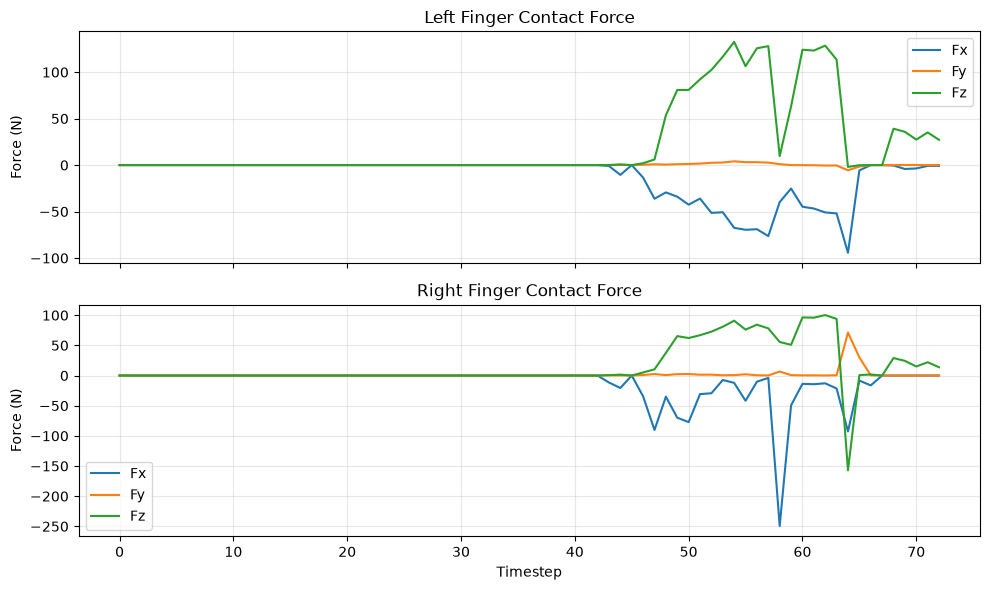

In [37]:
force_arr = np.stack(forces)  # (T, 6)
T = force_arr.shape[0]
t = np.arange(T)

left_force = force_arr[:, 0:3]   # fx, fy, fz for left finger
right_force = force_arr[:, 3:6]  # fx, fy, fz for right finger

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

labels = ['Fx', 'Fy', 'Fz']
for i in range(3):
    axes[0].plot(t, left_force[:, i], label=labels[i])
axes[0].set_title('Left Finger Contact Force')
axes[0].set_ylabel('Force (N)')
axes[0].legend()
axes[0].grid(alpha=0.3)

for i in range(3):
    axes[1].plot(t, right_force[:, i], label=labels[i])
axes[1].set_title('Right Finger Contact Force')
axes[1].set_ylabel('Force (N)')
axes[1].set_xlabel('Timestep')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
obs_sensor_data = dict_to_list_of_dicts(traj_h5["obs"]["sensor_data"])

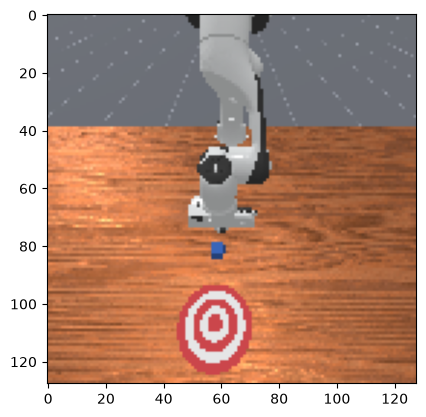

In [18]:
plt.imshow(obs_sensor_data[23]["base_camera"]["rgb"])

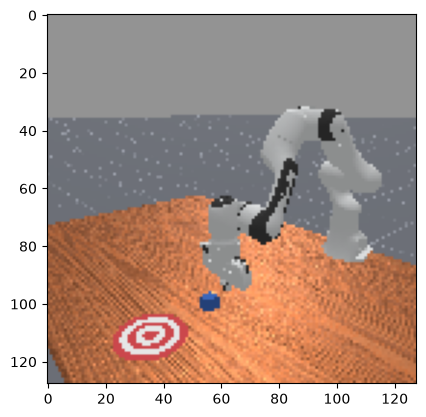

In [19]:
plt.imshow(obs_sensor_data[23]["side_camera"]["rgb"])